8. Feature Importance Analysis
Dataset: Bank Marketing Dataset

Download:
https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

Tasks
Train a Random Forest.

Find:

Top 10 Important Features
Create a bar chart showing feature importance.

Questions:

Which feature contributes the most?

Which features contribute the least?

Remove the least important 5 features and retrain the model.

Does accuracy change?



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(df.shape)

df.info()

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

In [5]:
#Convert Categorical Columns

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [6]:
X = df.drop("y", axis=1)

y = df["y"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", round(accuracy,4))

Accuracy : 0.9133


In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
10,duration,0.314350
18,euribor3m,0.105594
0,age,0.092222
19,nr.employed,0.064266
1,job,0.047824
11,campaign,0.042468
3,education,0.042242
9,day_of_week,0.041535
12,pdays,0.034755
14,poutcome,0.029701


In [11]:
top10 = importance.head(10)

print(top10)

        Feature  Importance
10     duration    0.314350
18    euribor3m    0.105594
0           age    0.092222
19  nr.employed    0.064266
1           job    0.047824
11     campaign    0.042468
3     education    0.042242
9   day_of_week    0.041535
12        pdays    0.034755
14     poutcome    0.029701


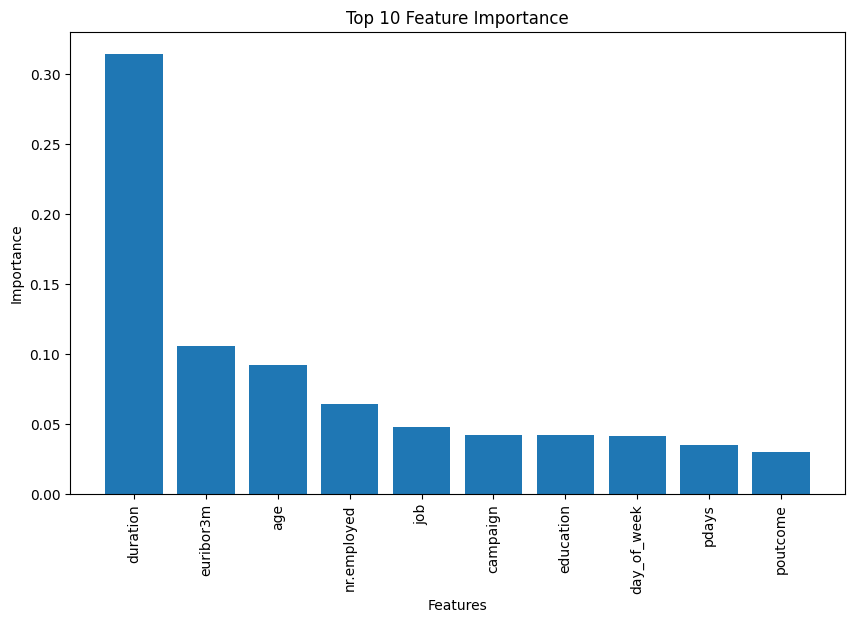

In [12]:
plt.figure(figsize=(10,6))

plt.bar(top10["Feature"], top10["Importance"])

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importance")

plt.show()

In [13]:
print("Most Important Feature")

print(top10.iloc[0])

Most Important Feature
Feature       duration
Importance     0.31435
Name: 10, dtype: object


In [14]:
least5 = importance.tail(5)

print(least5)

     Feature  Importance
8      month    0.019412
6       loan    0.015191
13  previous    0.012613
7    contact    0.010024
4    default    0.009101


In [15]:
least_features = least5["Feature"].tolist()

print("Removed Features")

print(least_features)

Removed Features
['month', 'loan', 'previous', 'contact', 'default']


In [16]:
X_new = X.drop(columns=least_features)

X_new.head()

,age,job,marital,education,housing,day_of_week,duration,campaign,pdays,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,3,1,0,0,1,261,1,999,1,1.1,93.994,-36.4,4.857,5191.0
1,57,7,1,3,0,1,149,1,999,1,1.1,93.994,-36.4,4.857,5191.0
2,37,7,1,3,2,1,226,1,999,1,1.1,93.994,-36.4,4.857,5191.0
3,40,0,1,1,0,1,151,1,999,1,1.1,93.994,-36.4,4.857,5191.0
4,56,7,1,3,0,1,307,1,999,1,1.1,93.994,-36.4,4.857,5191.0


In [17]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train2, y_train2)

RandomForestClassifier(random_state=42)

In [19]:
prediction2 = model2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, prediction2)

print("New Accuracy :", round(accuracy2,4))

New Accuracy : 0.9142


In [20]:
print("Original Accuracy :", round(accuracy,4))

print("New Accuracy      :", round(accuracy2,4))

if accuracy2 > accuracy:
    print("\nAccuracy Improved")

elif accuracy2 < accuracy:
    print("\nAccuracy Decreased")

else:
    print("\nAccuracy Stayed Same")

Original Accuracy : 0.9133
New Accuracy      : 0.9142

Accuracy Improved
